In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [4]:
img1 = cv2.imread("../Imagenes_cursado/parrafo0.jpg", cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread("../Imagenes_cursado/parrafo1.jpg", cv2.IMREAD_GRAYSCALE)


Para identificar si el texto está rotado podemos hacer un analisis en frecuencia.

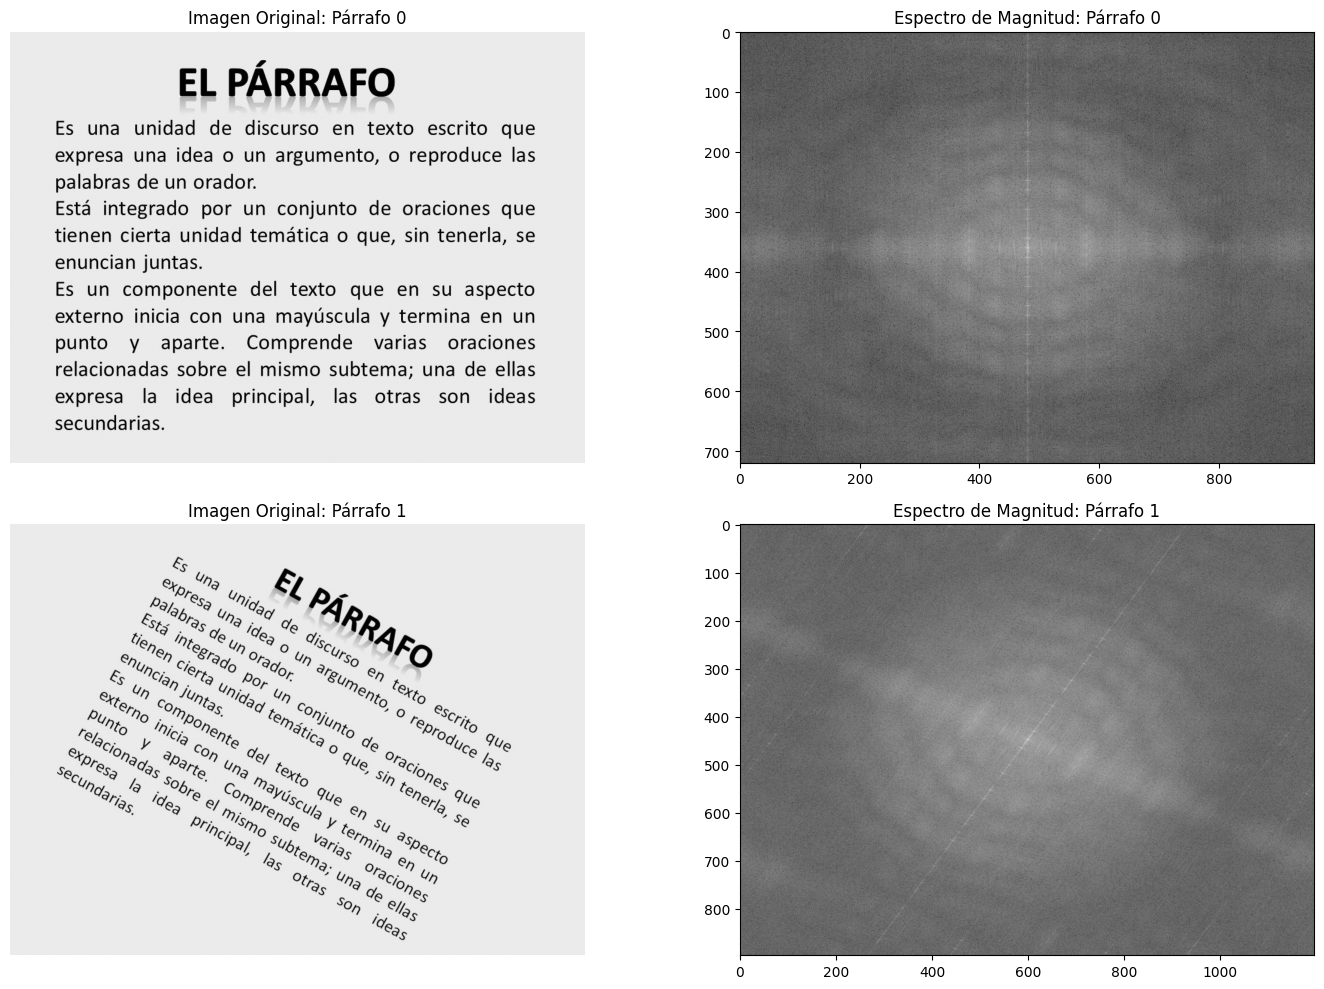

In [ ]:
def calcular_espectro(img):
    f = np.fft.fft2(img)
    fshift = np.fft.fftshift(f)
    
    magnitude_spectrum = 20 * np.log(np.abs(fshift) + 1)
    
    return fshift, magnitude_spectrum

# Calcular los espectros
f1_shift, mag1 = calcular_espectro(img1)
f2_shift, mag2 = calcular_espectro(img2)

# 2. Visualización
plt.figure(figsize=(15, 10))

# Imagen 1 y su FFT
plt.subplot(2, 2, 1)
plt.imshow(img1, cmap='gray')
plt.title('Imagen Original: Párrafo 0')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(mag1, cmap='gray')
plt.title('Espectro de Magnitud: Párrafo 0')

# Imagen 2 y su FFT
plt.subplot(2, 2, 3)
plt.imshow(img2, cmap='gray')
plt.title('Imagen Original: Párrafo 1')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(mag2, cmap='gray')
plt.title('Espectro de Magnitud: Párrafo 1')

plt.tight_layout()
plt.show()

Analizando los picos altos de la transformada, puedo unir la recta que los une a ambas frecuencia con una recta y calcular la pendiente angulo etc.

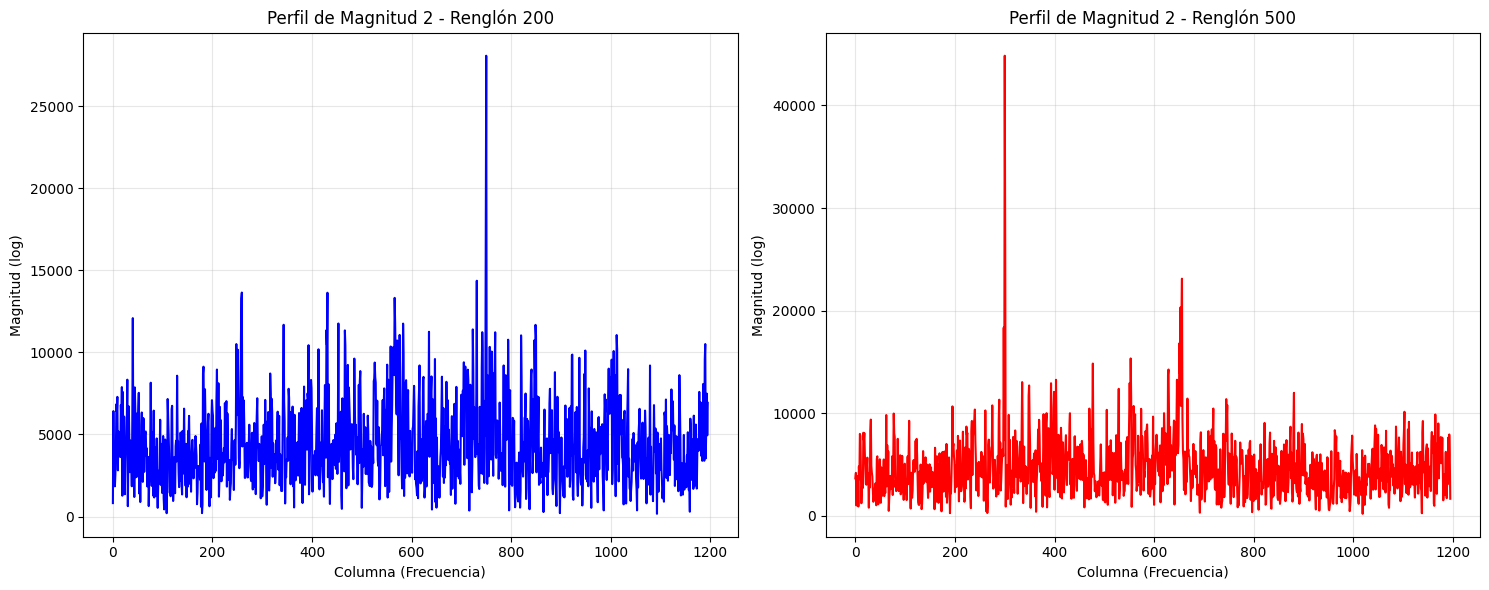

750 300
-1.0789871508061981


In [13]:
# 3. Visualización de perfiles para mag2
plt.figure(figsize=(15, 6))

# Perfil en el renglón 200
plt.subplot(1, 2, 1)
plt.plot(np.abs(f2_shift[10, :]), color='blue')
plt.title('Perfil de Magnitud 2 - Renglón 200')
plt.xlabel('Columna (Frecuencia)')
plt.ylabel('Magnitud (log)')
plt.grid(True, alpha=0.3)

# Perfil en el renglón 500
plt.subplot(1, 2, 2)
plt.plot(np.abs(f2_shift[850, :]), color='red')
plt.title('Perfil de Magnitud 2 - Renglón 500')
plt.xlabel('Columna (Frecuencia)')
plt.ylabel('Magnitud (log)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

idx_moda1 = np.argmax(np.abs(f2_shift[10, :]))
idx_moda2 = np.argmax(np.abs(f2_shift[850, :]))

print(idx_moda1, idx_moda2)

# ahora queda calcular el angulo que hay entre estos

theta = np.arctan((850 - 10)/(idx_moda2 - idx_moda1))
print(theta)

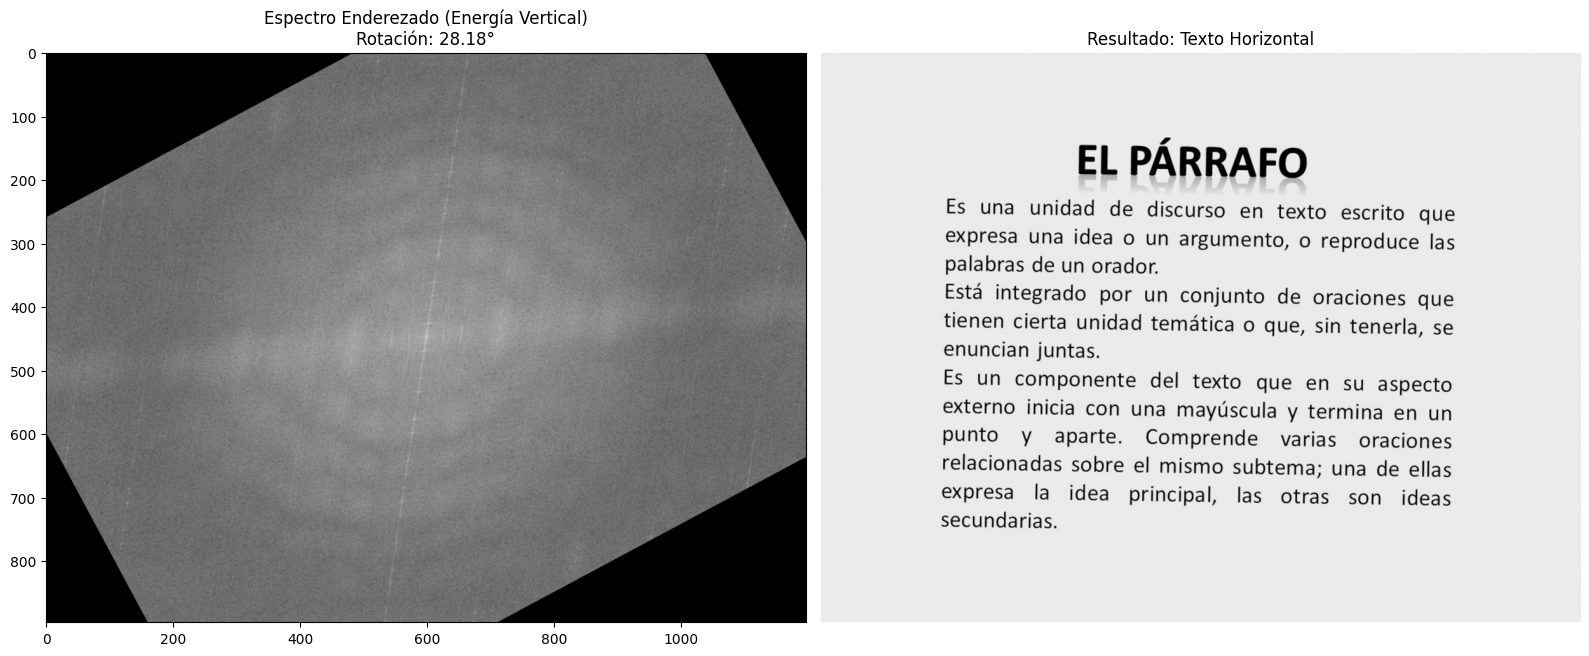

In [20]:

angulo_grados = np.degrees(theta)
rotacion = 90 + angulo_grados

(h, w) = img2.shape[:2]
centro = (w // 2, h // 2)

M = cv2.getRotationMatrix2D(centro, rotacion, 1.0)


mag2_rotada = cv2.warpAffine(mag2, M, (w, h))
img_final = cv2.warpAffine(img2, M, (w, h), flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_REPLICATE)


plt.figure(figsize=(16, 8))

plt.subplot(1, 2, 1)
plt.imshow(mag2_rotada, cmap='gray')
plt.title(f"Espectro Enderezado (Energía Vertical)\nRotación: {rotacion:.2f}°")


plt.subplot(1, 2, 2)
plt.imshow(img_final, cmap='gray')
plt.title(f"Resultado: Texto Horizontal")
plt.axis('off') 

plt.tight_layout()
plt.show()

el codigo es generico. Podria haber rotado la imagen y no el dominio frecuencial